# Разведочный анализ данных публикаций новостных сообществ московских вузов во ВКонтакте

## Описание данных

В проекте задействованы три набора данных: 'data_unis', 'data_with_comments', 'unis_ids'. Данные собраны из 90 новостных сообществ вузов г. Москвы в социальной сети "ВКонтакте", содержат информацию о публикациях, пользовательских реакциях и комментариях.

### `data_unis`

Датасет является основным, содержит все собранные публикации из сообществ.
Размер датасета 345006 строк x 8 столбцов.
Одна строка содержит данные одной публикации.

| Столбец | Тип данных | Описание | 
|---|------:|---|
|`post_id`| `int64`| Уникальный идентификатор публикации на стене сообщества|
|`date`| `object`| Дата публикации|
|`text`| `object`| Текст публикации|
|`likes`| `int64`| Число лайков на публикации|
|`comments_count`| `int64`| Число комментариев на публикации|
|`reposts`| `int64`| Число репостов на публикации|
|`views`| `int64`| Число просмотров на публикации|
|`source_nickname`| `object`| Название csv-файла, соответствующего источнику данных|

### `data_with_comments`

Датасет содержит публикации, для которых были выгружены тексты комментариев.
Размер датасета 99280 строк x 11 столбцов.
Одна строка содержит данные одной публикации с комментариями, перечисленными через  ` | `.

| Столбец | Тип данных | Описание | 
|---|------:|---|
|`post_id`| `int64`| Уникальный идентификатор публикации на стене сообщества|
|`date`| `object`| Дата публикации|
|`text`| `object`| Текст публикации|
|`likes`| `int64`| Число лайков на публикации|
|`comments_count`| `int64`| Число комментариев на публикации|
|`reposts`| `int64`| Число репостов на публикации|
|`views`| `int64`| Число просмотров на публикации|
|`source_nickname`| `object`| Название csv-файла, соответствующего источнику данных|
|`group_id`| `float64`| Уникальный идентификатор сообщества|
|`post_link`| `object`| Ссылка на публикацию|
|`comments`| `object`| Тексты комментариев к публикации, объединенные в одну строку|

### `unis_ids`

Датасет-справочник соответствия между названиями источников данных и идентификаторами сообществ.
Размер датасета 90 строк x 2 столбцов.

| Столбец | Тип данных | Описание | 
|---|------:|---|
|`group_id`| `float64`| Уникальный идентификатор сообщества|
|`source_nickname`| `object`| Название csv-файла, соответствующего источнику данных|

### Связь между наборами данных

`data_unis` – содержит полный набор собранных публикаций.
`data_with_comments` – является подмножеством `data_unis`, с дополнением в виде текстов комментариев в публикациях с их наличием.
`unis_ids` – вспомогательный справочник, используемый для добавления `group_id` к публикациям в `data_with_comments`.

Связь по `source_nickname`.


## Импорт библиотек и настройка параметров отображения элементов

In [15]:
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

In [16]:
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.float_format', lambda x:f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
sns.set_palette('pastel')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'Times New Roman'

## Загрузка данных и просмотр их структуры

In [17]:
data_unis = pd.read_csv('/Users/ekaterinamalkova/Desktop/vkr_analysis/data/data_unis.csv')
data_with_comments = pd.read_csv('/Users/ekaterinamalkova/Desktop/vkr_analysis/data/data_with_comments.csv')
unis_ids = pd.read_csv('/Users/ekaterinamalkova/Desktop/vkr_analysis/data/unis_ids.csv')

data_unis.name = 'data_unis'
data_with_comments = data_with_comments.drop(columns=['Unnamed: 0'])
data_with_comments.name = 'data_with_comments'
unis_ids.name = 'unis_ids'

In [18]:
for df in [data_unis, data_with_comments, unis_ids]:
    display(Markdown(f'### Первые строки {df.name}'))
    display(df.head(3))

### Первые строки data_unis

,post_id,date,text,likes,comments_count,reposts,views,source_nickname
0,77031,2025-12-31,"🎄 Не хотим отвлекать вас от салатно-гирляндных хлопот, но праздник уже на носу — а значит, настало время для поздравлений\n\nСамые теплые новогодн...",42,0,5,4951,hse.csv
1,77030,2025-12-30,"🎄 Чем запомнился уходящий год для Вышки?\n\nРазработками и исследованиями, проектами и партнерствами, новыми образовательными программами и простр...",44,0,2,6790,hse.csv
2,77028,2025-12-30,"🌳 Зеленая трансформация: от мифов к реалиям \n\nКак климатическая политика, трансформация энергетики и технологические инновации становятся взаимо...",20,0,3,3091,hse.csv


### Первые строки data_with_comments

,post_id,date,text,likes,comments_count,reposts,views,source_nickname,group_id,post_link,comments
0,77019,2025-12-29,"🤨 Понимают ли нейросети каламбуры?\n\nНе очень: у больших языковых моделей с этим явно пробLLMы, выяснила международная команда с участием исследо...",16,1,4,3546,hse.csv,"-25,205,856.00",https://vk.com/club25205856?w=wall-25205856_77019,"ДА!Вы-лучшие!Докажите, что нашего брата этой коробке не переплюнуть, не заткнуть за пояс и мы ему еще покажем кузькину...Дальше сами вссе догадают..."
1,76983,2025-12-23,"🏅 Наука, бизнес, благотворительность, спорт: выпускники Вышки успешны во всем\n\nЭто показали итоги Премии выдающихся выпускников университета — 2...",57,2,1,12237,hse.csv,"-25,205,856.00",https://vk.com/club25205856?w=wall-25205856_76983,Amazing
2,76975,2025-12-22,"🤖 ИСКРА, АЛЕКС и МИРА — лучшие ИИ-наставники\n\nИменно эти проекты заняли призовые места в номинации «Дизайн-код цифрового наставника» на федераль...",31,1,2,7496,hse.csv,"-25,205,856.00",https://vk.com/club25205856?w=wall-25205856_76975,а кто у вас младший директор?


### Первые строки unis_ids

,group_id,source_nickname
0,-25205856,hse.csv
1,-50409684,mai.csv
2,-78019879,mgu.csv


In [19]:
def df_info(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({'dtype': df.dtypes.astype(str),
                         'not_na': df.notna().sum(),
                         'missing': df.isna().sum(),
                         'nunique': df.nunique()}).sort_index()
for df in [data_unis, data_with_comments, unis_ids]:
    display(Markdown(f'### Базовая информация о датафрейме {df.name}'))
    display(df_info(df))

### Базовая информация о датафрейме data_unis

,dtype,not_na,missing,nunique
comments_count,int64,345006,0,505
date,object,345006,0,2192
likes,int64,345006,0,1302
post_id,int64,345006,0,97768
reposts,int64,345006,0,600
source_nickname,object,345006,0,90
text,object,345006,0,340345
views,int64,345006,0,26716


### Базовая информация о датафрейме data_with_comments

,dtype,not_na,missing,nunique
comments,object,99280,0,92301
comments_count,int64,99280,0,504
date,object,99280,0,2192
group_id,float64,99280,0,90
likes,int64,99280,0,1271
post_id,int64,99280,0,63590
post_link,object,99280,0,99273
reposts,int64,99280,0,584
source_nickname,object,99280,0,90
text,object,99280,0,98538


### Базовая информация о датафрейме unis_ids

,dtype,not_na,missing,nunique
group_id,int64,90,0,90
source_nickname,object,90,0,90


In [20]:
data_unis.duplicated().sum()

np.int64(2)

In [21]:
for df in [data_unis, data_with_comments, unis_ids]:
    display(Markdown(f'### Дубликаты в {df.name}'))
    display(df[df.duplicated(keep=False)])
data_unis= data_unis.drop_duplicates()
data_with_comments= data_with_comments.drop_duplicates()
unis_ids= unis_ids.drop_duplicates()
data_unis.name = 'data_unis'
data_with_comments.name = 'data_with_comments'
unis_ids.name = 'unis_ids'

### Дубликаты в data_unis

,post_id,date,text,likes,comments_count,reposts,views,source_nickname
91515,25734,2025-11-19,"🇷🇺 Преподаватели Первого по праву – основа качества образования\n\n19 ноября в России отмечается День преподавателя высшей школы – значимая дата, ...",177,1,4,10797,kutafina.csv
91516,25734,2025-11-19,"🇷🇺 Преподаватели Первого по праву – основа качества образования\n\n19 ноября в России отмечается День преподавателя высшей школы – значимая дата, ...",177,1,4,10797,kutafina.csv
231520,72738,2025-09-29,🤩 26 сентября в РУС «ГЦОЛИФК» прошел День профориентации!\n\n✨️ Спортсменки от 8 до 14 лет из спортивно-хореографической студии Азены Оствальд пос...,48,0,1,4012,gtsolifk.csv
231521,72738,2025-09-29,🤩 26 сентября в РУС «ГЦОЛИФК» прошел День профориентации!\n\n✨️ Спортсменки от 8 до 14 лет из спортивно-хореографической студии Азены Оствальд пос...,48,0,1,4012,gtsolifk.csv


### Дубликаты в data_with_comments

,post_id,date,text,likes,comments_count,reposts,views,source_nickname,group_id,post_link,comments
32741,25734,2025-11-19,"🇷🇺 Преподаватели Первого по праву – основа качества образования\n\n19 ноября в России отмечается День преподавателя высшей школы – значимая дата, ...",177,1,4,10797,kutafina.csv,"-65,417.00",https://vk.com/club65417?w=wall-65417_25734,Спасибо вам за ваш труд💙
32742,25734,2025-11-19,"🇷🇺 Преподаватели Первого по праву – основа качества образования\n\n19 ноября в России отмечается День преподавателя высшей школы – значимая дата, ...",177,1,4,10797,kutafina.csv,"-65,417.00",https://vk.com/club65417?w=wall-65417_25734,Спасибо вам за ваш труд💙


### Дубликаты в unis_ids

,group_id,source_nickname


In [22]:
for df in [data_unis, data_with_comments]:
    display(Markdown(f'### Временной период публикаций в {df.name}'))
    print(f'Минимальная дата: {df.date.min()}')    
    print(f'Максимальная дата: {df.date.max()}')

### Временной период публикаций в data_unis

Минимальная дата: 2020-01-01
Максимальная дата: 2025-12-31


### Временной период публикаций в data_with_comments

Минимальная дата: 2020-01-01
Максимальная дата: 2025-12-31


## Преобразование типов данных и создание новых переменных

In [23]:
def words_counter(series: pd.Series) -> pd.Series:
    return series.fillna('').astype(str).str.findall(r'\b\w+\b').str.len()

In [24]:
for df in [data_unis, data_with_comments]:
    df['date'] = pd.to_datetime(df['date'])
    
    for col in ['likes', 'comments_count', 'reposts', 'views']:
        df[col] = pd.to_numeric(df[col])

    df['year'] = df['date'].dt.year.astype('Int64')
    df['month'] = df['date'].dt.month.astype('Int64')
    df['year_month'] = df['date'].dt.to_period('M')
    df['weekday'] = df['date'].dt.day_name()
    df['weekday_num'] = df['date'].dt.dayofweek.astype('Int64')
    df['week_number'] = df['date'].dt.isocalendar().week

    text_ser = df['text'].fillna('').astype(str)
    df['text_len'] = text_ser.str.len()
    df['text_word_cnt'] = words_counter(text_ser)

    if 'comments' in df.columns:
        comm_ser = df['comments'].fillna('').astype(str)
        df['comments_len'] = comm_ser.str.len()
        df['comments_word_cnt_mean'] = words_counter(comm_ser) / df['comments_count']

    df['engagement'] = df[['likes', 'comments_count', 'reposts']].sum(axis=1, min_count=1)
    df['engagement_rate'] = np.where(df['views'].fillna(0) >0,
                                    df['engagement'] / df['views'],
                                    np.nan,)

## Функции для визуализации и анализа

In [25]:
def plot_tops_bar(data, title, xlabel, ylabel='', n=20):
    data = data.sort_values(ascending=False).head(n).sort_values(ascending=True)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=data.values, y=data.index, color='#4C78A8')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.bar_label(plt.gca().containers[0], fmt='%.0f', fontsize=9)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

def plot_log_hist(data, columns, title):
    fig, axes = plt.subplots(2, 2, figsize=(12,8))
    axes = axes.ravel()
    for ax, col in zip(axes, columns):
        sns.histplot(np.log1p(data[col]), bins=50, ax=ax, color='#4C78A8')
        ax.set_title(f'{title}: {col}')
        ax.set_xlabel(f'log(1+{col})')
        ax.set_ylabel('Количество публикаций')    
    plt.tight_layout()
    plt.show()

def iqr(data, columns):
    rows = []
    for col in columns:
        values = data[col]
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        up = q3 + 1.5 * iqr

        rows.append({'metric': col,
                    'min': values.min(),
                    'q1': q1,
                    'median': values.median(),
                    'q3': q3,
                    'max': values.max(),
                    'iqr_up_threshold': up,
                    'iqr_low_threshold': low,
                    'outliers_above_iqr': (values > up).sum(),
                    'outliers_under_iqr': (values < low).sum(),
                    'total_outliers': ((values < low) | (values > up)).sum()})
    return pd.DataFrame(rows)

def find_top_posts(data, metric, n=10):
    columns = ['source_nickname', 'post_id', 'date', 'text', 'likes',
              'comments_count', 'reposts', 'views', 'engagement', 'engagement_rate']
    tops = data.sort_values(metric, ascending=False).head(n)[columns]
    tops['text'] = tops['text'].fillna('').astype(str)
    tops['text'] = tops['text'].str.replace('\n', ' ').str.strip()
    for i in range(len(tops)):
        if len(tops.iloc[i]['text']) > 200:
            tops.iloc[i, tops.columns.get_loc('text')] = tops.iloc[i]['text'][:200] + '...'
    
    
    return tops

## Анализ в динамике

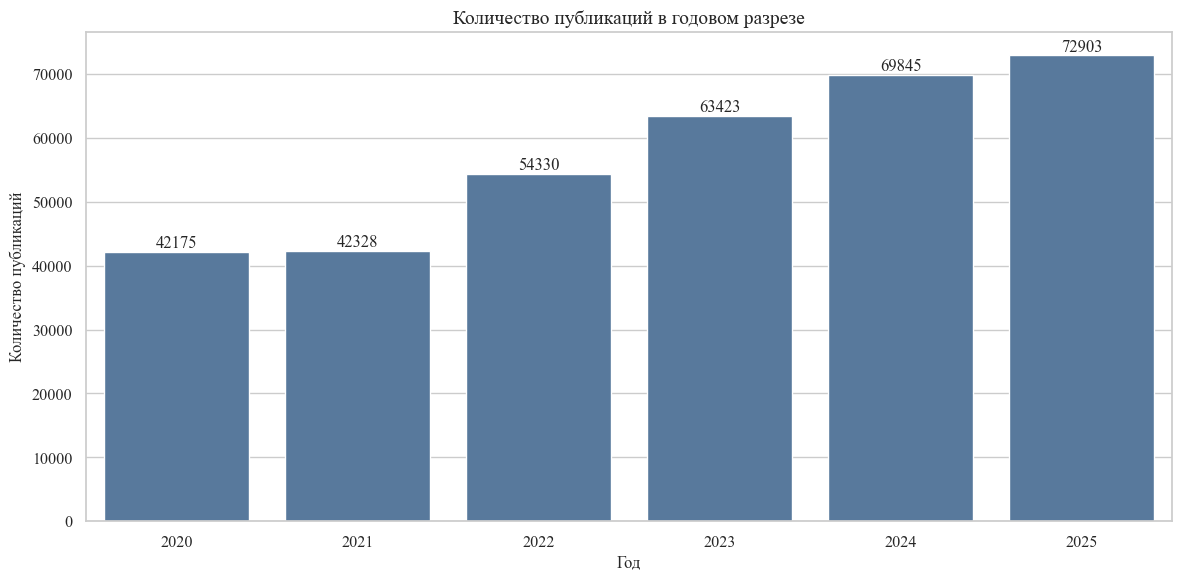

In [26]:
posts_through_years = data_unis.groupby('year').size()

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=posts_through_years.index.astype(str), y=posts_through_years.values,
            ax=ax, color='#4C78A8')
ax.set_title('Количество публикаций в годовом разрезе')
ax.set_xlabel('Год')
ax.set_ylabel('Количество публикаций')
ax.bar_label(ax.containers[0], fmt='%.0f', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Наибольшее число публикаций приходится на 2025 год – 72903 постов.  

Максимальное число публикаций концентрируется в апреле 2025, с чуть более, чем 7000 постами.  
Визуально можно отметить цикличные периоды подъема и падения публикационной активности каждые полгода.

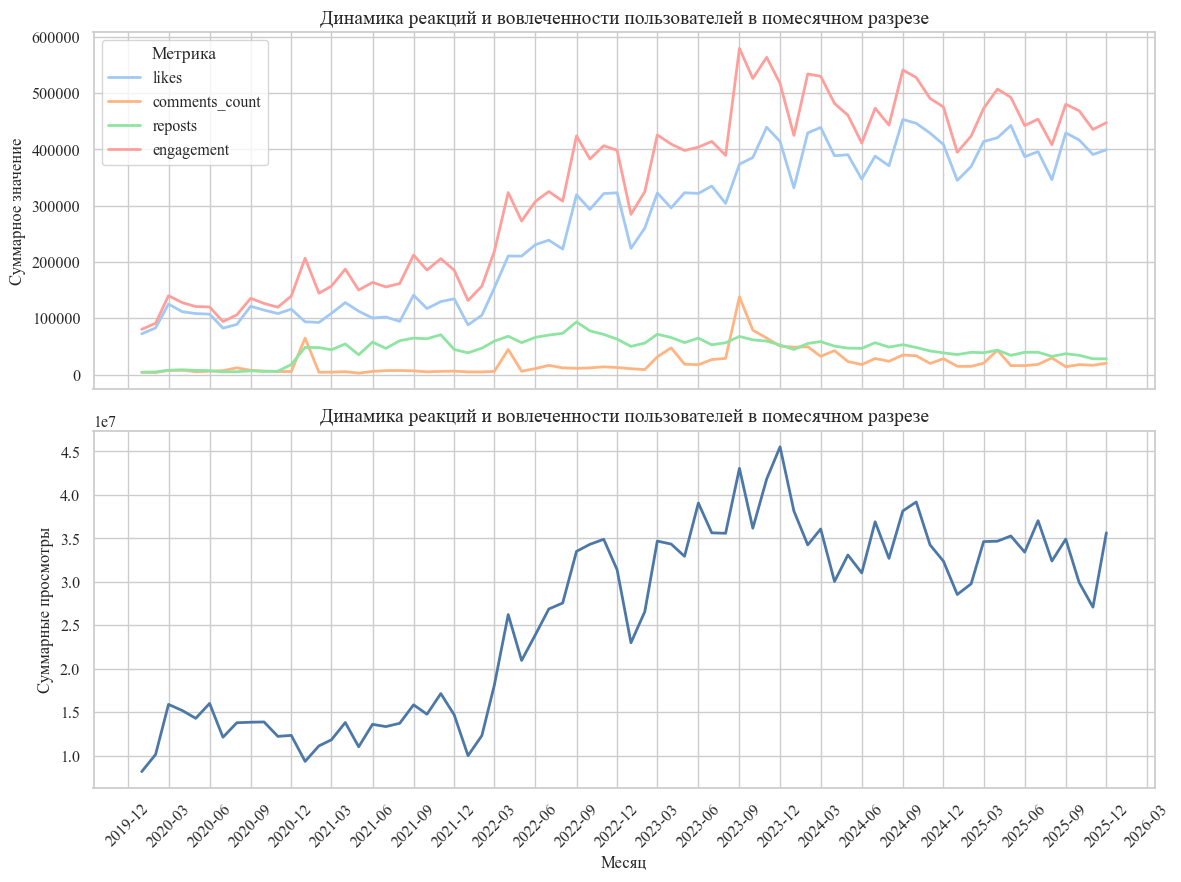

In [27]:
monthly_reactions = data_unis.groupby('year_month')[['likes', 'comments_count',
                                                    'reposts', 'views', 'engagement']].sum().sort_index()

monthly_reactions.index = monthly_reactions.index.to_timestamp()



fig, axes = plt.subplots(2, 1, figsize=(12,9), sharex=True)
for col in ['likes', 'comments_count','reposts', 'engagement']:
    sns.lineplot(data=monthly_reactions, x=monthly_reactions.index, y=col, ax=axes[0], label=col, linewidth=2)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
axes[0].set_title('Динамика реакций и вовлеченности пользователей в помесячном разрезе')
axes[0].set_xlabel('')
axes[0].set_ylabel('Суммарное значение')
axes[0].legend(title='Метрика')

sns.lineplot(data=monthly_reactions, x=monthly_reactions.index, y='views', ax=axes[1], color='#4C78A8', linewidth=2)
axes[1].set_title('Динамика реакций и вовлеченности пользователей в помесячном разрезе')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Суммарные просмотры')
plt.tight_layout()
plt.show()

Можно отметить особенность проявления пользовательской активности: лайки ставят более охотно, чем делают репосты и оставляют комментарии. Последние – наименее популярный подвид пользовательского вовлечения в контент.  
Также наблюдается резкий рост числа просмотров и проявления активности в конце 2021 года.

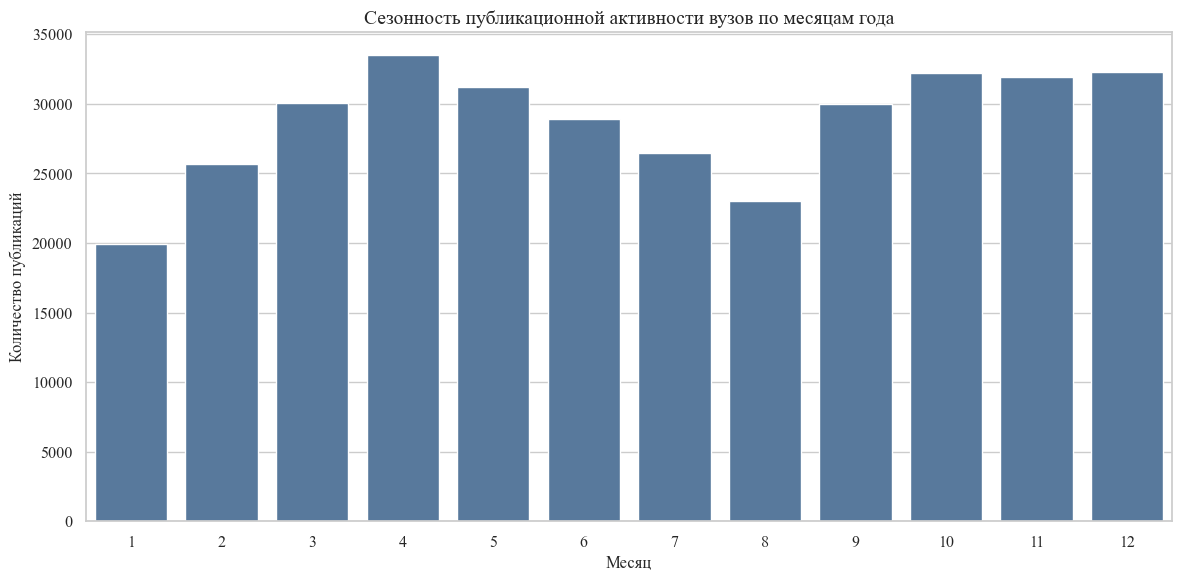

,posts,median_engagement,mean_engagement
month,,,
1,19888,32.00,76.59
2,25642,30.00,65.33
3,30054,30.00,64.72
4,33475,27.00,60.85
5,31230,29.00,60.69
6,28887,29.00,64.02
7,26432,32.00,72.50
8,23029,37.00,78.90
9,30014,37.00,79.05


In [28]:
month_seasons = data_unis.groupby('month').agg(posts=('post_id', 'count'), median_engagement=('engagement', 'median'), mean_engagement=('engagement', 'mean'))

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=month_seasons.index, y=month_seasons['posts'], ax=ax, color='#4C78A8')
ax.set_title('Сезонность публикационной активности вузов по месяцам года')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество публикаций')
plt.tight_layout()
plt.show()

display(month_seasons)

Публикационная активность сообществ вузов распределена неравномерно в течение года. Пик приходится на апрель, далее много публикаций выкладывается в октябре, ноябре и декабре; в январе происходит резкий спад числа публикаций.  
При этом месяцы с наибольшей публикационной активностью не всегда совпадают с месяцами максимальной вовлеченности пользователей: например, высокие значения медианной вовлеченности в контент наблюдаются в августе и сентябре, вероятно, это указывает на особую значимость периода начала учебного года и завершения приемной кампании.

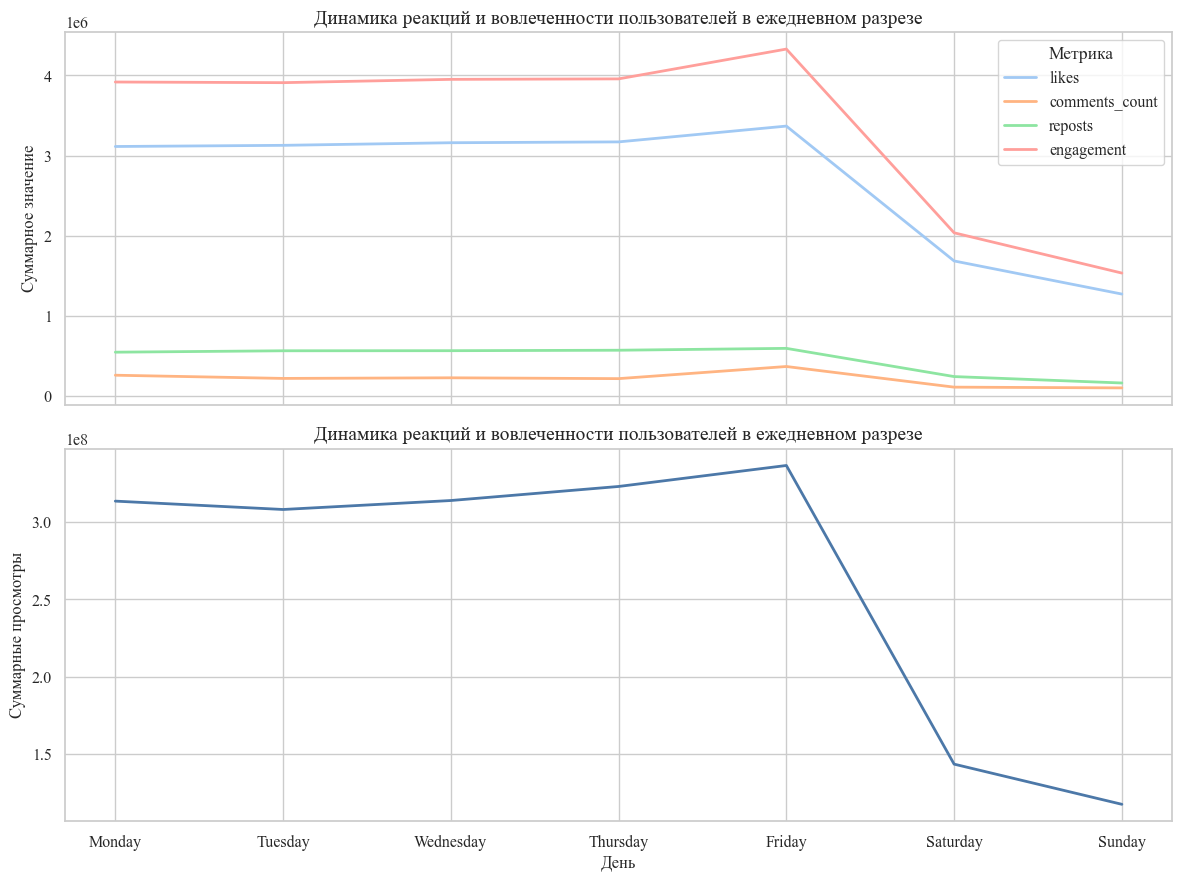

In [29]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_reactions = data_unis.groupby('weekday')[['likes', 'comments_count',
                                                    'reposts', 'views', 'engagement']].sum().reindex(day_order)

fig, axes = plt.subplots(2, 1, figsize=(12,9), sharex=True)
for col in ['likes', 'comments_count','reposts', 'engagement']:
    sns.lineplot(data=daily_reactions, x=daily_reactions.index, y=col, ax=axes[0], label=col, linewidth=2)
plt.xticks(rotation=0)
axes[0].set_title('Динамика реакций и вовлеченности пользователей в ежедневном разрезе')
axes[0].set_xlabel('')
axes[0].set_ylabel('Суммарное значение')
axes[0].legend(title='Метрика')

sns.lineplot(data=daily_reactions, x=daily_reactions.index, y='views', ax=axes[1], color='#4C78A8', linewidth=2)
axes[1].set_title('Динамика реакций и вовлеченности пользователей в ежедневном разрезе')
axes[1].set_xlabel('День')
axes[1].set_ylabel('Суммарные просмотры')
plt.tight_layout()
plt.show()

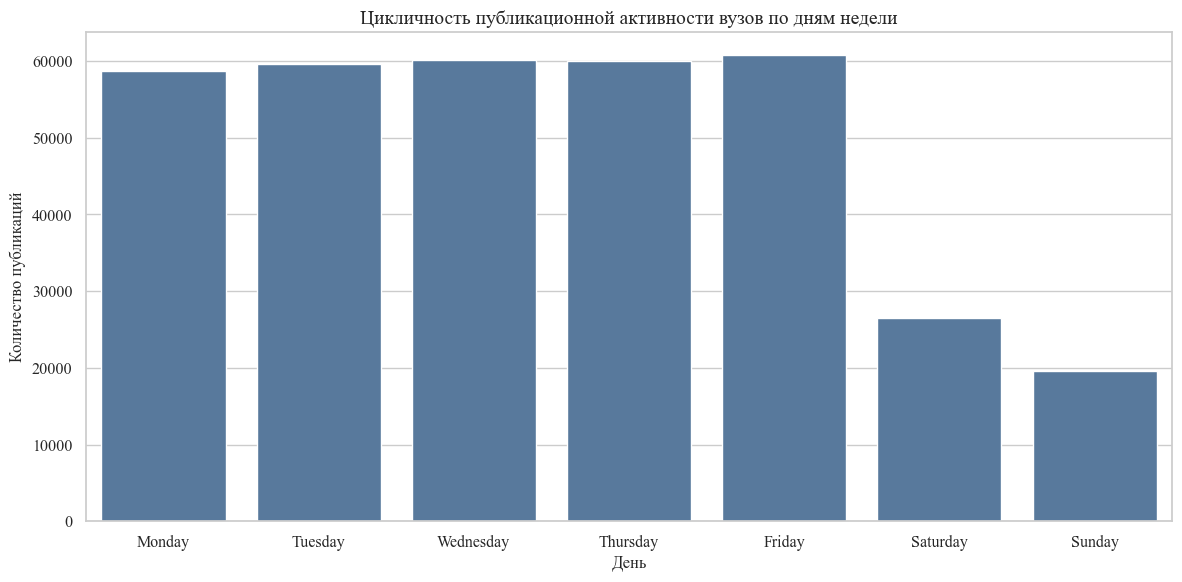

,posts,median_engagement,mean_engagement
weekday,,,
Monday,58671,31.00,66.78
Tuesday,59578,30.00,65.62
Wednesday,60122,30.00,65.72
Thursday,59922,30.00,66.04
Friday,60713,31.00,71.30
Saturday,26428,35.00,77.04
Sunday,19570,34.00,78.35


In [30]:
day_seasons = data_unis.groupby('weekday').agg(posts=('post_id', 'count'), median_engagement=('engagement', 'median'), mean_engagement=('engagement', 'mean')).reindex(day_order)

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=day_seasons.index, y=day_seasons['posts'], ax=ax, color='#4C78A8')
ax.set_title('Цикличность публикационной активности вузов по дням недели')
ax.set_xlabel('День')
ax.set_ylabel('Количество публикаций')
plt.tight_layout()
plt.show()

display(day_seasons)

На графиках видна специфика функционирования рабочей недели в стране: с понедельника по пятницу вовлеченность в контент выше, чем в выходные субботу и воскресенье.

## Анализ публикационной активности вузов

Публикационная активность – динамика публикации контента в сообществе вуза.  
Вовлеченность – пользовательские реакции на публикуемый вузами контент.  
Эти понятия следует различать по следующец причине: сообщество может публиковать много контента и получать при этом низкую активность от подписчиков, или наоборот – иметь меньшее число публикаций, но высокую реакцию со стороны пользователей.

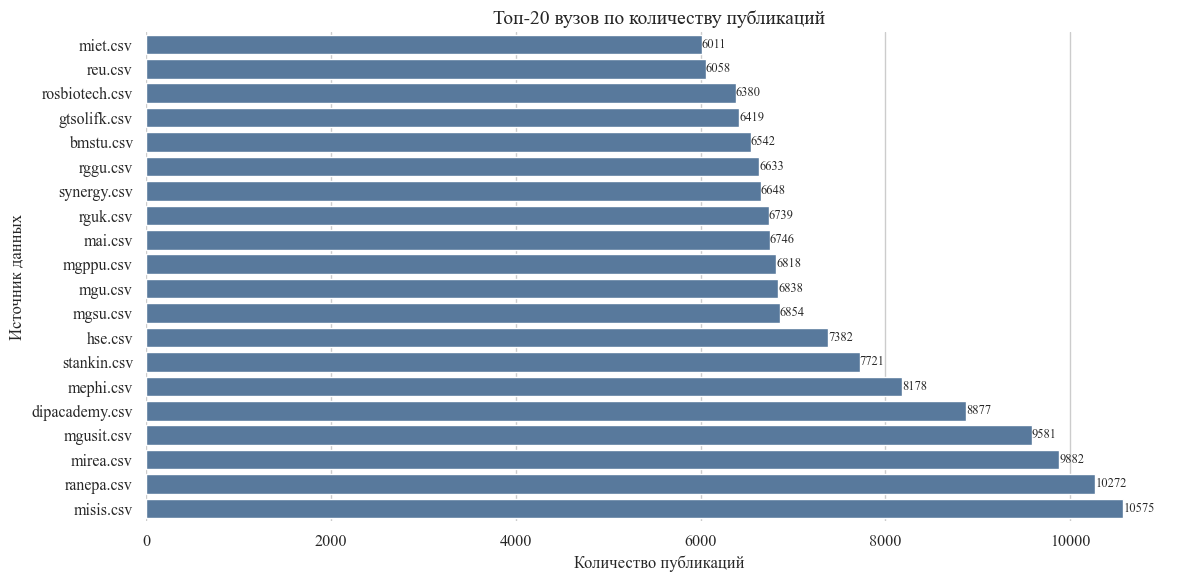

In [31]:
posts_source = data_unis['source_nickname'].value_counts()
plot_tops_bar(data=posts_source, title='Топ-20 вузов по количеству публикаций',
              xlabel='Количество публикаций', ylabel='Источник данных', n=20)

В полной таблице представлено 90 источников. Наиболее высокая публикационная активность у МИСИС – 10575 публикаций.

In [32]:
reactions_source = (data_unis.groupby('source_nickname').agg(
    posts=('post_id', 'count'),
    mean_likes=('likes', 'mean'),
    median_likes=('likes', 'median'),
    mean_comments=('comments_count', 'mean'),
    median_comments=('comments_count', 'median'),
    mean_reposts=('reposts', 'mean'),
    median_reposts=('reposts', 'median'),
    mean_views=('views', 'mean'),
    median_views=('views', 'median'),
    mean_engagement=('engagement', 'mean'),
    median_engagement=('engagement', 'median')).sort_values('posts', ascending=False))

display(reactions_source.head(20))

,posts,mean_likes,median_likes,mean_comments,median_comments,mean_reposts,median_reposts,mean_views,median_views,mean_engagement,median_engagement
source_nickname,,,,,,,,,,,
misis.csv,10575,87.95,31.00,2.79,0.00,11.09,5.00,"7,454.62","3,781.00",101.84,47.00
ranepa.csv,10272,63.18,28.00,1.66,0.00,11.66,3.00,"7,782.99","4,985.50",76.50,33.00
mirea.csv,9882,182.97,82.00,43.39,13.00,16.65,5.00,"11,536.46","5,104.00",243.01,117.00
mgusit.csv,9581,34.50,25.00,0.84,0.00,2.05,1.00,"1,542.22","1,188.00",37.38,27.00
dipacademy.csv,8877,17.00,11.00,0.19,0.00,3.34,1.00,"1,436.35","1,141.00",20.53,13.00
mephi.csv,8178,26.99,14.00,0.50,0.00,6.46,3.00,"3,488.47","2,640.50",33.95,18.00
stankin.csv,7721,29.53,23.00,2.12,0.00,5.19,3.00,"2,353.54","1,808.00",36.85,28.00
hse.csv,7382,31.68,17.00,0.99,0.00,11.72,4.00,"11,133.17","5,660.50",44.39,22.00
mgsu.csv,6854,34.46,19.00,0.01,0.00,5.15,2.00,"4,283.01","1,884.50",39.62,22.00


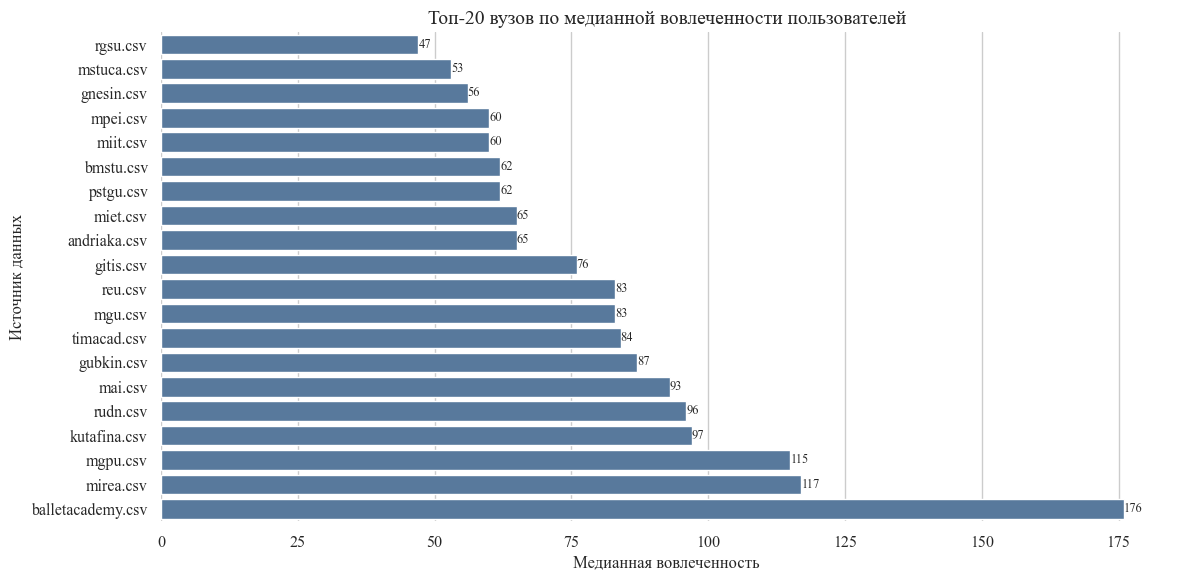

In [33]:
plot_tops_bar(data=reactions_source['median_engagement'], title='Топ-20 вузов по медианной вовлеченности пользователей',
              xlabel='Медианная вовлеченность', ylabel='Источник данных', n=20)

Таблица отражает топ-20 самых публикационно активных вузов в сопоставлении со средними и медианными пользовательскими реакциями (лайки, комментарии, репосты, просмотры и суммарный показатель вовлеченности).  
 

Среди наиболее активных сообществ можно отметить МИСИС, РАНХиГС, МИРЭА, МГУСиТ и ДипАкадемию. Однако, таблица наглядно демонстрирует тезис о том, то высокая публикационная активность не всегда сопровождается высокой пользовательской вовлеченностью. Так, наиболее заметные показатели вовлеченности у МГАХ, МИРЭА, МГПУ. Это указывает на то, что лидеры вузов по числу публикаций не обязательно являются лидерами по числу реакций, поэтому необходимо разделять понятия интенсивной публикации и реакции аудитории – первая отражает активность сообщества, а вторая – дают характеристику о пользовательском отклике на контент.

## Анализ пользовательских реакций

Природа взаимодействия в социальных сетях такова, что часто распределение пользовательских реакций является сильно скошенным: большинство публикацию получается умеренное число реакций, но небольшое число публикаций может собирать довольно большие значения реакций. Всвязи с этим стоит обратить внимание на логарфмированное распределение реакций.

In [34]:
reactions = ['likes', 'comments_count', 'reposts', 'views', 'engagement']
desc_reactions = data_unis[reactions].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(desc_reactions)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
likes,"345,004.00",54.77,119.86,0.00,1.00,4.00,12.00,25.00,58.00,194.00,423.00,"13,083.00"
comments_count,"345,004.00",4.34,186.76,0.00,0.00,0.00,0.00,0.00,1.00,10.00,61.00,"61,061.00"
reposts,"345,004.00",9.40,32.29,0.00,0.00,0.00,1.00,3.00,9.00,34.00,99.00,"3,983.00"
views,"345,004.00","5,378.99","16,719.18",6.00,237.00,558.00,"1,521.00","2,925.00","5,514.00","14,767.00","35,799.94","1,839,627.00"
engagement,"345,004.00",68.50,236.91,0.00,1.00,5.00,14.00,31.00,71.00,238.00,529.00,"61,325.00"


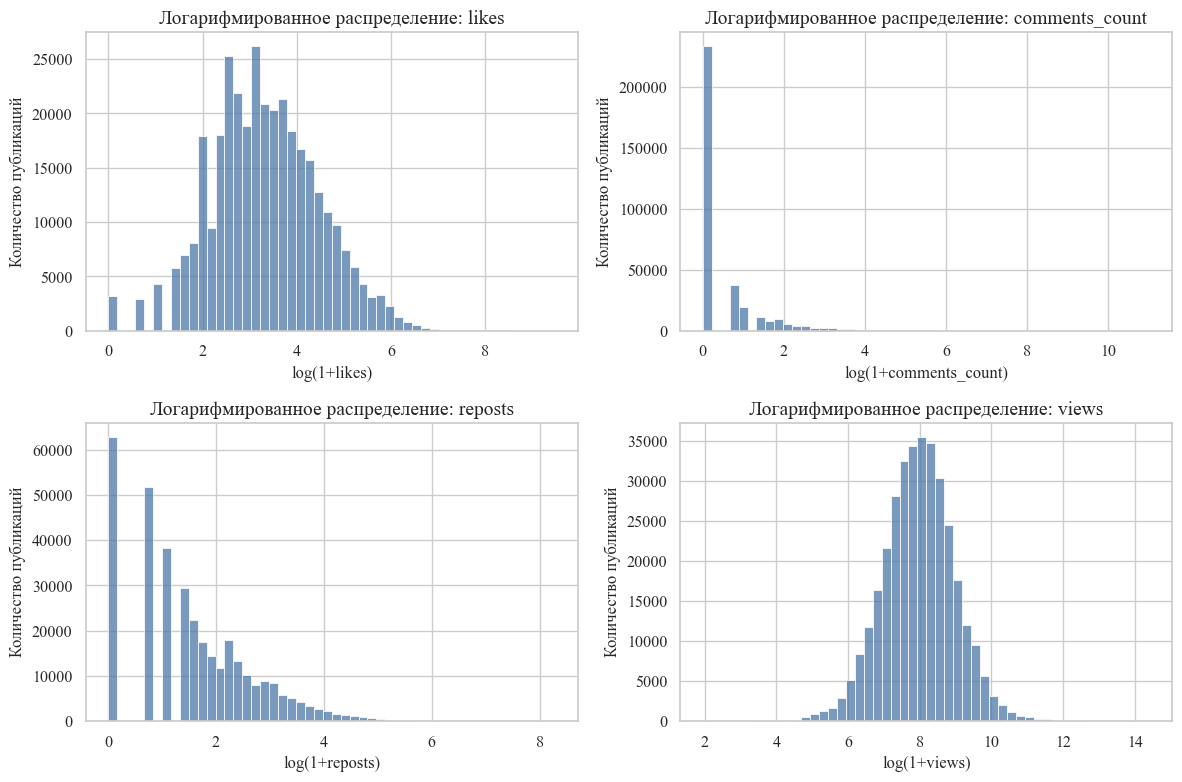

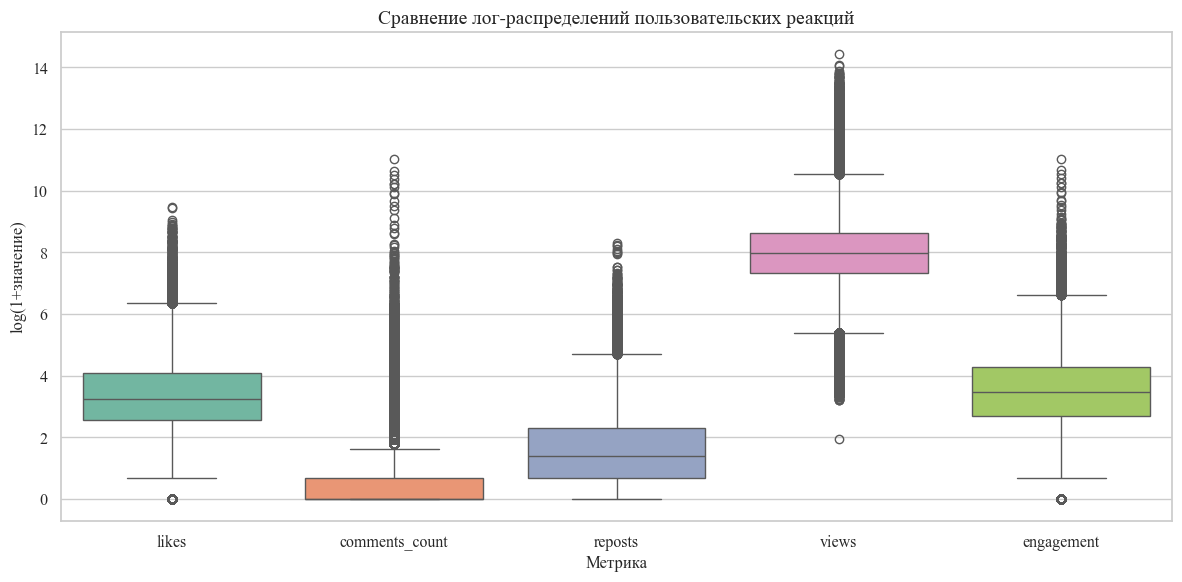

In [35]:
plot_log_hist(data=data_unis, columns=reactions, title='Логарифмированное распределение')

fig, ax = plt.subplots(figsize=(12,6))
log_box = np.log1p(data_unis[reactions])
sns.boxplot(data=log_box, ax=ax, palette='Set2')
ax.set_title('Сравнение лог-распределений пользовательских реакций')
ax.set_xlabel('Метрика')
ax.set_ylabel('log(1+значение)')
plt.tight_layout()
plt.show()

In [36]:
outliers = iqr(data=data_unis, columns=reactions)
display(outliers)

,metric,min,q1,median,q3,max,iqr_up_threshold,iqr_low_threshold,outliers_above_iqr,outliers_under_iqr,total_outliers
0,likes,0,12.00,25.00,58.00,13083,127.00,-57.00,33368,0,33368
1,comments_count,0,0.00,0.00,1.00,61061,2.50,-1.50,54134,0,54134
2,reposts,0,1.00,3.00,9.00,3983,21.00,-11.00,32143,0,32143
3,views,6,"1,521.00","2,925.00","5,514.00",1839627,"11,503.50","-4,468.50",27811,0,27811
4,engagement,0,14.00,31.00,71.00,61325,156.50,-71.50,32737,0,32737


Таблица показывает проверку данных на выбросы в соответствие с размером межквартильного размаха.  
Большинство постов получает умеренное число лайков, но есть группа публикаций с довольно высоким пользовательским откликом.  
Среди комментариев распределение скошенно сильнее всего. Серединная публикаци набирает мало комментариев, но некоторые отдельные посты собирают очень большие обсуждения.  
Та же картина наблюдается и с неравномерным распределением репостов.  
Среди просмотров заметен более длинный хвост справа – некоторые посты охватили аудиторию большую, чем типичный уровень внимания к их контенту.  

Таким образом, мы подтвердили, что реакции пользователей распределяются неравномерно среди публикаций: небольшая часть контента получает очень высокий отклик, в то время как основная масса публикаций – сравнительно умеренные значения отклика.

## Анализ текстов публикаций

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
text_len,"345,004.00",801.91,712.07,1.00,27.00,95.00,362.00,637.00,"1,028.00","2,029.00","3,428.00","16,384.00"
text_word_cnt,"345,004.00",103.13,92.46,0.00,3.00,12.00,47.00,82.00,131.00,260.00,446.00,"2,372.00"


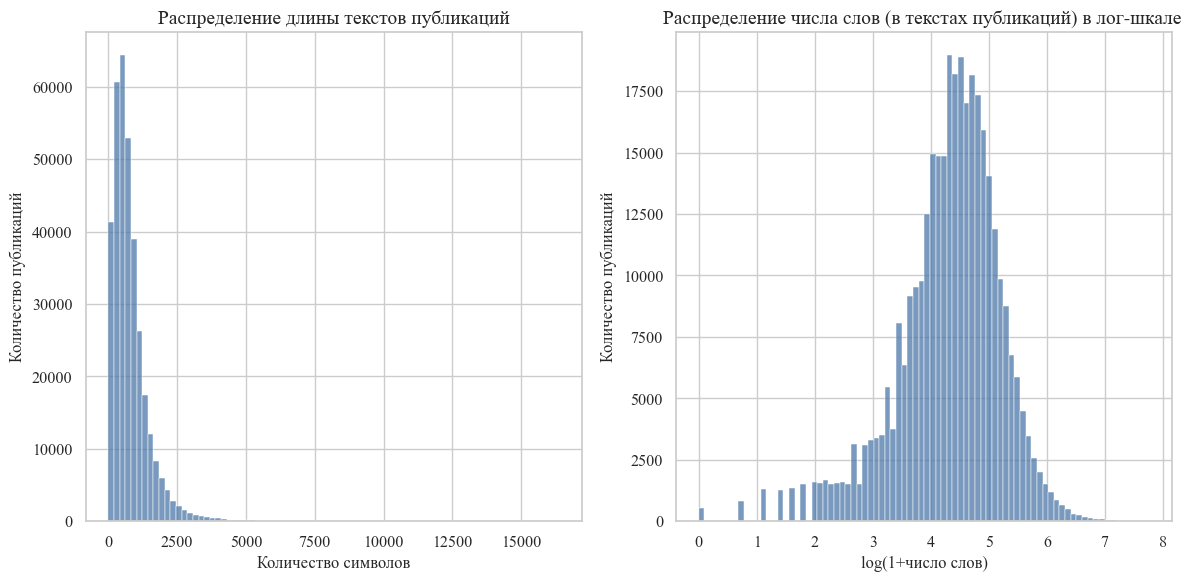

In [37]:
text_metrics = ['text_len', 'text_word_cnt']
desc_text_metrics = data_unis[text_metrics].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(desc_text_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.histplot(data_unis['text_len'], bins=80, ax=axes[0], color='#4C78A8')
axes[0].set_title('Распределение длины текстов публикаций')
axes[0].set_xlabel('Количество символов')
axes[0].set_ylabel('Количество публикаций')


sns.histplot(np.log1p(data_unis['text_word_cnt']), bins=80, ax=axes[1], color='#4C78A8')
axes[1].set_title('Распределение числа слов (в текстах публикаций) в лог-шкале ')
axes[1].set_xlabel('log(1+число слов)')
axes[1].set_ylabel('Количество публикаций')

plt.tight_layout()
plt.show()

Можно заметить, что в среднем пост содержит 802 символа или 103 слова, медиана же – 637 символов или 82 слова. Эти показатели говорят о скошенном вправо распределении: большая часть текстов в публикациях имеет умеренную длину, но есть небольшая доля публикаций с очень длинными текстами. Также в выборке присутствуют публикации с одним сиволом, вероятно, эмодзи. 

,text_len,engagement,text_word_cnt,engagement_rate
text_len,1.00,-0.01,0.99,-0.06
engagement,-0.01,1.00,-0.01,0.54
text_word_cnt,0.99,-0.01,1.00,-0.06
engagement_rate,-0.06,0.54,-0.06,1.00


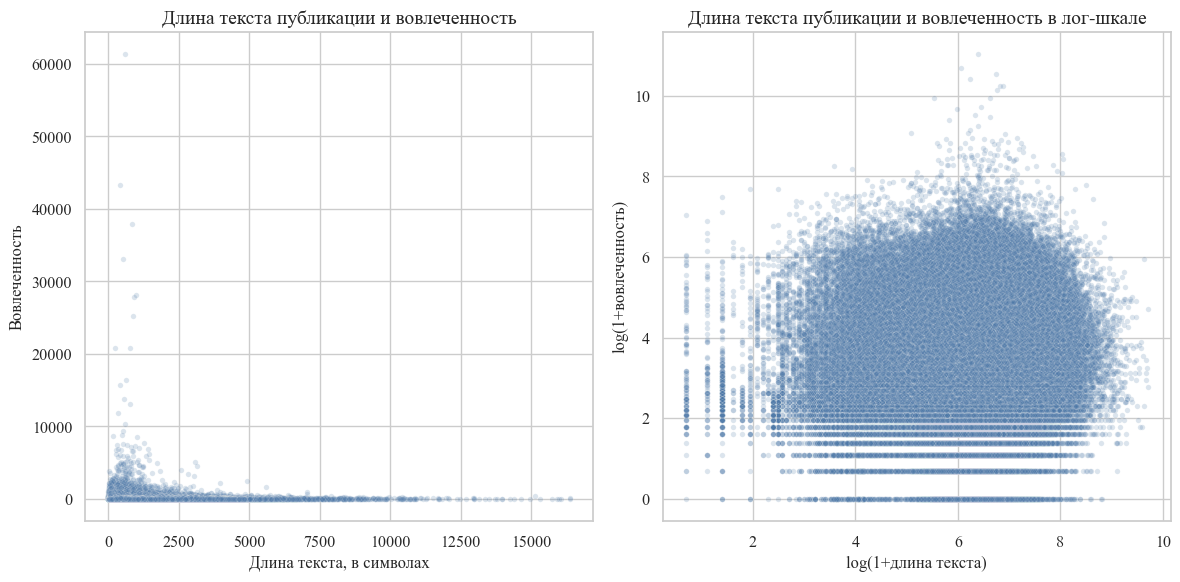

In [38]:
data_unis['engagement_rate'] = np.where(data_unis['views'] > 0, data_unis['engagement'] / data_unis['views'], np.nan)

text_corr = data_unis[['text_len', 'engagement', 'text_word_cnt', 'engagement_rate']].corr(method='spearman')
display(text_corr)

fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.scatterplot(data=data_unis, x='text_len', y='engagement',
               s=15, alpha=0.2, ax=axes[0], color='#4C78A8')
axes[0].set_title('Длина текста публикации и вовлеченность')
axes[0].set_xlabel('Длина текста, в символах')
axes[0].set_ylabel('Вовлеченность')

sns.scatterplot(data=data_unis, x=np.log1p(data_unis['text_len']), 
                y=np.log1p(data_unis['engagement']),
               s=15, alpha=0.2, ax=axes[1], color='#4C78A8')
axes[1].set_title('Длина текста публикации и вовлеченность в лог-шкале')
axes[1].set_xlabel('log(1+длина текста)')
axes[1].set_ylabel('log(1+вовлеченность)')
plt.tight_layout()
plt.show()


По выведенной матрице корреляций нельзя сказать, то длина текста публикации существенно влияет на показатели вовлеченности.  

In [39]:
for metric, title in [('likes', 'Топ-10 публикаций по числу лайков'),
                     ('comments_count', 'Топ-10 публикаций по числу комментариев'),
                     ('reposts', 'Топ-10 публикаций по числу репостов'),
                     ('views', 'Топ-10 публикаций по числу просмотров')]:
    display(Markdown(f'### {title}'))
    display(find_top_posts(data_unis, metric, n=10))

### Топ-10 публикаций по числу лайков

,source_nickname,post_id,date,text,likes,comments_count,reposts,views,engagement,engagement_rate
175461,polytech.csv,16517,2021-05-20,"🛩 ФЕСТИВАЛЬ «НЕБО: ТЕОРИЯ И ПРАКТИКА — 2021» 🛩 Московский Политех примет участие в фестивале [club73803838|«НЕБО: теория и практика — 2021»], кот...",13083,0,4,24035,13087,0.54
153310,rguk.csv,41595,2021-01-15,ПРИГОТОВЬСЯ СТАТЬ СТУДЕНТОМ 3...2...1 🔥 Мы начинаем трансляцию первого в России Погружения в РГУ им. А.Н. Косыгина для школьников❗ Посещение нау...,12463,215,3796,122187,16474,0.13
30554,mirea.csv,131526,2023-11-19,"Ваня, спасай! – 39 серия Паше становится плохо, но Ваня бежит на помощь. Способен ли Паша проявить благодарность за спасение своей жизни? #ваняс...",8495,174,18,868605,8687,0.01
28982,mirea.csv,348126,2024-08-28,"Ямал — это не просто место на карте, а целая маленькая вселенная, полная загадок, неизведанных тайн и красивых легенд. Именно здесь, среди бескрай...",8096,405,22,189357,8523,0.05
28889,mirea.csv,360066,2024-09-12,"Агафья Карповна Лыкова — последняя представительница уникальной семьи, выбравшей путь полного уединения. Её история, символ необычной и сложной жи...",7447,225,19,60517,7691,0.13
29159,mirea.csv,334687,2024-07-27,Около 100 тонн мусора собрали участники [club224725824|Студенческого экспедиционного корпуса «Команда Арктики»] на судне «Михаил Сомов». Студен...,7206,118,119,112081,7443,0.07
27783,mirea.csv,417104,2025-03-10,"🔥 Осталось совсем немного времени до грандиозного мероприятия, посвящённого празднованию дня рождения Студенческого экспедиционного корпуса «Коман...",7011,318,17,44669,7346,0.16
28234,mirea.csv,399025,2024-12-16,Заместитель начальника Главного военно-политического управления Вооружённых сил Российской Федерации Апти Алаутдинов посетил РТУ МИРЭА. Известн...,7007,134,60,87198,7201,0.08
29173,mirea.csv,331327,2024-07-25,На Ямале — пора сбора иван-чая. Участники Студенческого экспедиционного корпуса «Команда Арктики» приехали в Салехард для изучения полезных каче...,6658,144,30,73871,6832,0.09
29335,mirea.csv,318858,2024-06-27,"Холод и лёд — это первые ассоциации, которые приходят на ум, когда люди слышат об Арктике. Но на самом деле этот регион скрывает в себе множество ...",6605,185,176,261153,6966,0.03


### Топ-10 публикаций по числу комментариев

,source_nickname,post_id,date,text,likes,comments_count,reposts,views,engagement,engagement_rate
68102,rudn.csv,54782,2021-01-29,"В нашей галактике более 100 миллиардов звезд и более 800 миллиардов планет. Одна из них — планета РУДН, на которой тоже есть свои звезды — студент...",208,61061,56,14087,61325,4.35
9808,mai.csv,105478,2023-09-29,Проголодались? 👀 Начинаем великую маёвскую битву за набор горячей пиццы от наших друзей — проекта [https://vk.com/znanie_igra|«Знание.Игра»] 🍕 ...,757,42464,74,11849,43295,3.65
102976,gubkin.csv,19246,2022-04-13,"В преддверии Дня губкинца ищем нефть! На нашей карте нанесены 92 нефтяных месторождения, из которых можно добыть ценные призы. Правила поисково-...",526,36964,494,65381,37984,0.58
30701,mirea.csv,86518,2023-10-30,"🍕 Где самая вкусная пицца? Правильно, в РТУ МИРЭА! В честь открытия нового пункта питания, расположенного под главной лестницей в корпусе на пр...",196,32721,130,21095,33047,1.57
100294,gubkin.csv,98419,2025-04-06,"В День геолога начинаем геологоразведочные работы! На нашей карте нанесены 35 нефтегазовых месторождений, из которых можно добыть ценные призы (и...",345,27651,142,24151,28138,1.17
102107,gubkin.csv,59985,2023-04-17,"В День Губкинца начинаем поисково-разведочные работы! На нашей карте нанесены 35 нефтегазовых месторождений, из которых можно добыть ценные призы...",419,27227,244,47941,27890,0.58
340990,reu.csv,128424,2023-09-07,"Привет, обещали розыгрыш с 10 призами? Вот он! Бесплатные поездки на городском велосипеде? Легко! Для этого есть Велобайк - городской велопрок...",51,25106,12,7078,25169,3.56
341012,reu.csv,107748,2023-09-01,Дарим худи РЭУ. РФ самому активному подписчику! Правила участия просты - больше стикеров в комментариях под этой записью - больше шанс выиграть! ...,306,20524,36,365214,20866,0.06
29758,mirea.csv,270574,2024-04-09,"Внимание! Розыгрыш пиццы🍕! Мы знаем, как вы любите хрустящие наггетсы, горячую картошку и пиццу с тянущимся сыром, поэтому с радостью сообщаем ...",527,20141,103,9770,20771,2.13
10620,mai.csv,52451,2023-03-17,"«Я – МАЁВЕЦ», – звучит гордо! 💙 Если это прозвучит 93 000 раз – будет лучший подарок к 93-летию МАИ, которое мы отметим 20 марта 👉🏻👈🏻 🎁 Подгото...",99,15593,51,5327,15743,2.96


### Топ-10 публикаций по числу репостов

,source_nickname,post_id,date,text,likes,comments_count,reposts,views,engagement,engagement_rate
241223,inpsyho.csv,12266,2022-04-22,"5 психологических экспериментов, которые вас удивят Люди не такие, какими вы себе их представляли. Это легко доказать необычными и даже шокирующи...",6324,0,3983,1277579,10307,0.01
153310,rguk.csv,41595,2021-01-15,ПРИГОТОВЬСЯ СТАТЬ СТУДЕНТОМ 3...2...1 🔥 Мы начинаем трансляцию первого в России Погружения в РГУ им. А.Н. Косыгина для школьников❗ Посещение нау...,12463,215,3796,122187,16474,0.13
62659,bmstu.csv,26761,2021-04-23,Дни с 1 по 10 мая объявляются праздничными и нерабочими. Президент РФ Владимир Путин поддержал предложение главы Роспотребнадзора Анны Поповой сд...,774,34,3639,46931,4447,0.09
62180,bmstu.csv,30976,2021-11-18,"С 24 ноября университет возобновляет работу в очном формате #новости@bmstu1830 Вход будет осуществляться преимущественно по цифровым пропускам*, ...",615,2,3365,54576,3982,0.07
81504,fa.csv,39391,2021-11-19,"⚡ВОЗВРАЩАЕМСЯ К ОЧНОМУ ФОРМАТУ ОБУЧЕНИЯ С 29 НОЯБРЯ ⚡ Руководство Финансового университета приняло решение о том, что с 29 ноября 2021 года час...",447,345,3133,27514,3925,0.14
66991,rudn.csv,120783,2022-06-30,"Площадь перед Главным корпусом РУДН. Сотни выпускников делают селфи, обнимаются, бросают в воздух конфедератки.🎓 👩🏻Аннагуль — одна из них, лучшая ...",5704,116,2982,166457,8802,0.05
62256,bmstu.csv,30207,2021-10-21,Вышел приказ №02.01-03/1018 о работе Университета в период с 28 октября по 7 ноября #новости@bmstu1830 Согласно приказу: 🔹В эти даты Университет ...,515,27,2883,50710,3425,0.07
153069,rguk.csv,43266,2021-07-05,Не пропусти «ДЕНЬ ОТКРЫТЫХ ВОЗМОЖНОСТЕЙ» для абитуриентов! Присоединяйся к нашей трансляции на YouTube и в ВКонтакте! 😎 🔹https://youtu.be/so...,4361,453,2821,27236,7635,0.28
81874,fa.csv,32206,2021-06-12,"⚡️ Михаил Эскиндаров: «С 14.06.2021 все занятия, консультации, экзамены и ГИА переносятся в режим онлайн…» Следите за новостями. В течение часа ...",596,59,1870,29979,2525,0.08
241035,inpsyho.csv,15266,2022-11-25,"8 психологических эффектов, которые искажают восприятие реальности Ловили себя на мысли, что все вокруг замечают ваши несовершенства? Знаете люд...",3304,3,1836,487902,5143,0.01


### Топ-10 публикаций по числу просмотров

,source_nickname,post_id,date,text,likes,comments_count,reposts,views,engagement,engagement_rate
20463,mgu.csv,15827,2020-06-28,"Лекция ректора МГУ Виктора Садовничего для российских выпускников 2020 года👩🏻‍🎓 29 июня в 12:00 президент Российского Союза ректоров, ректор МГУ ...",271,6,15,1839627,292,0.00
339698,reu.csv,181843,2024-11-17,Повышение квалификации: Управление продажами: реальные инструменты бизнеса Хотите улучшить свои навыки продаж и увеличить прибыль? Тогда курс п...,192,0,4,1285454,196,0.00
241223,inpsyho.csv,12266,2022-04-22,"5 психологических экспериментов, которые вас удивят Люди не такие, какими вы себе их представляли. Это легко доказать необычными и даже шокирующи...",6324,0,3983,1277579,10307,0.01
10253,mai.csv,77931,2023-06-15,"Просто и понятно – о новой системе образования и о том, что изменится в МАИ уже в этом году. На дне открытых дверей ректор университета Михаил ...",77,5,31,1060443,113,0.00
9074,mai.csv,191587,2024-05-05,"В гостях у #МАИподкасты — музыкант, журналист, автор книг и просветительских проектов Ляля Кандаурова. Её книга — «Как слушать музыку» — учит слуш...",702,7,82,1012571,791,0.00
242699,madi.csv,6137,2023-06-06,"#приёмка2023@university_madi Уже очень скоро, а именно 20 июня, МАДИ откроет свои двери для подачи документов поступающими! Вы сможете подать до...",13,2,20,1004239,35,0.00
339755,reu.csv,181529,2024-10-23,"Как стать экспертом в области банкротства и знать законодательную основу? Ответ найден вместе с Плехановским университетом ""Единая программа по...",142,3,11,970912,156,0.00
165334,synergy.csv,80485,2025-07-11,"Поступай в Университет «Синергия» с гарантией трудоустройства: ведущий вуз для твоей карьеры 🦏 Все ступени образования: колледж, бакалавриат, маг...",144,0,37,967647,181,0.00
339455,reu.csv,183590,2025-02-27,Мастер делового администрирования (MBA) Плехановский университет продолжает набор на программы МВА. Это высокая ступень в сфере бизнес-образован...,147,0,9,940211,156,0.00
9947,mai.csv,86648,2023-09-01,"Они готовят тебе вкусный обед. Заботятся о твоей безопасности. Снимают на видео твои успехи, чтобы с гордостью выложить в соцсетях. Нет, мы не ...",1442,35,285,911613,1762,0.00


Наиболее залайканные публикации посвящены новостям и достижениям университета.  
Оказалось, что публикации с большим числом комментариев являются конкурсами, механика участия в которых включает оставление комментария.  
Среди постов с большим числом репостов можно выделить посты, связанные с ковидными ограничениями внутри вуза, посты с интересными фактами или достижениями и посты для абитуриентов.
Для постов с большим числом просмотров справедливо сказать, что они принадлежат публикациям с рассказом об образовательных программах, а также важных событиях вроде лекции от ректора.

## Анализ текстов комментариев

In [40]:
display(Markdown(f'Доля публикаций, имеющих текстовые комментарии: {round(data_with_comments.shape[0] * 100 / data_unis.shape[0], 2)}%'))

Доля публикаций, имеющих текстовые комментарии: 28.78%

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
comments_count,"99,279.00",14.75,347.92,1.00,1.00,1.00,1.00,3.00,7.00,41.00,142.00,"61,061.00"
comments_len,"99,279.00",349.53,"4,121.41",1.00,1.00,5.00,32.00,83.00,222.00,"1,209.00","3,923.22","922,343.00"
comments_len_mean,"99,279.00",55.34,205.66,0.00,0.83,2.67,12.50,25.88,50.00,161.00,474.00,"16,384.00"
comments_word_cnt_mean,"99,279.00",7.81,30.86,0.00,0.00,0.00,1.57,3.50,7.00,23.00,68.54,"2,904.00"


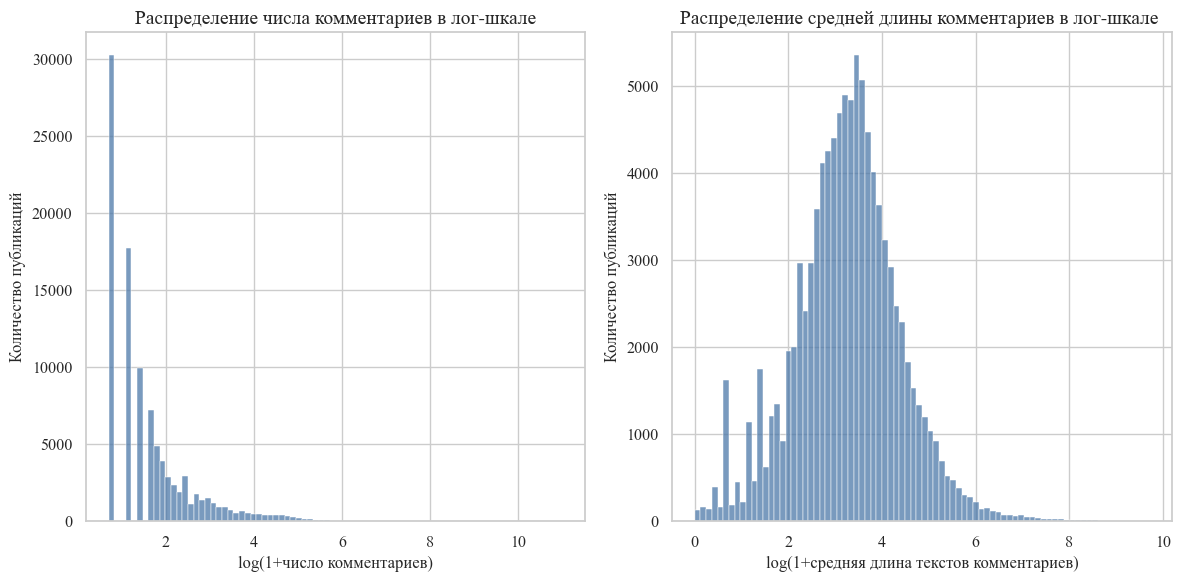

In [41]:
data_with_comments['comments_len_mean'] = data_with_comments['comments_len'] / data_with_comments['comments_count']
comm_cols = ['comments_count', 'comments_len', 'comments_len_mean', 'comments_word_cnt_mean']
desc_comm_metrics = data_with_comments[comm_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

display(desc_comm_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.histplot(np.log1p(data_with_comments['comments_count']), bins=80, ax=axes[0], color='#4C78A8')
axes[0].set_title('Распределение числа комментариев в лог-шкале')
axes[0].set_xlabel('log(1+число комментариев)')
axes[0].set_ylabel('Количество публикаций')

sns.histplot(np.log1p(data_with_comments['comments_len_mean']), bins=80, ax=axes[1], color='#4C78A8')
axes[1].set_title('Распределение средней длины комментариев в лог-шкале ')
axes[1].set_xlabel('log(1+средняя длина текстов комментариев)')
axes[1].set_ylabel('Количество публикаций')

plt.tight_layout()
plt.show()

Можно заметить, что в медиане пост содержит 3 комментария длинной 83 символов каждый, в среднем – 14 комментариев на пост по 99 символов. Эти показатели говорят о скошенном вправо распределении: большая часть публикаций получает мало комментариев, но есть отдельные посты с очень большим числом комментариев. Мы уже увидели ранее, что в их число входят и посты-конкурсы.  
Формат обсуждений неоднороден, комментариев может быть немного, но они будут длинные, или наоборот, много коротких комменатриев.

,comments_count,comments_len,comments_word_cnt_mean,engagement,likes,views,reposts
comments_count,1.00,0.61,-0.17,0.52,0.44,0.34,0.26
comments_len,0.61,1.00,0.58,0.34,0.28,0.25,0.19
comments_word_cnt_mean,-0.17,0.58,1.00,-0.11,-0.11,-0.02,0.00
engagement,0.52,0.34,-0.11,1.00,0.97,0.74,0.64
likes,0.44,0.28,-0.11,0.97,1.00,0.71,0.53
views,0.34,0.25,-0.02,0.74,0.71,1.00,0.59
reposts,0.26,0.19,0.00,0.64,0.53,0.59,1.00


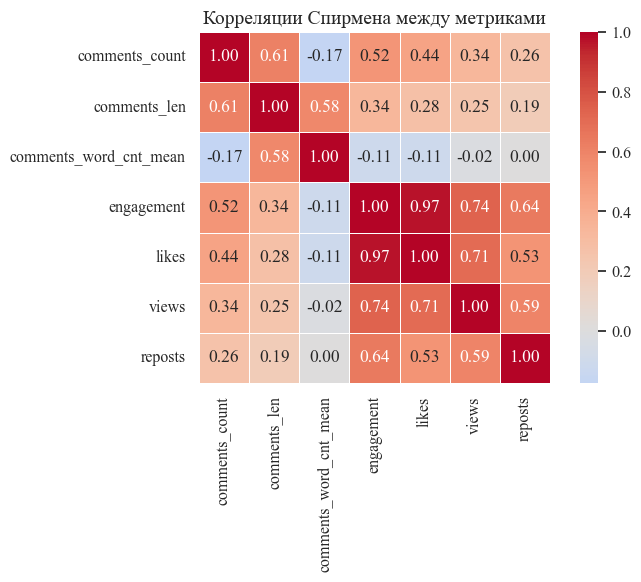

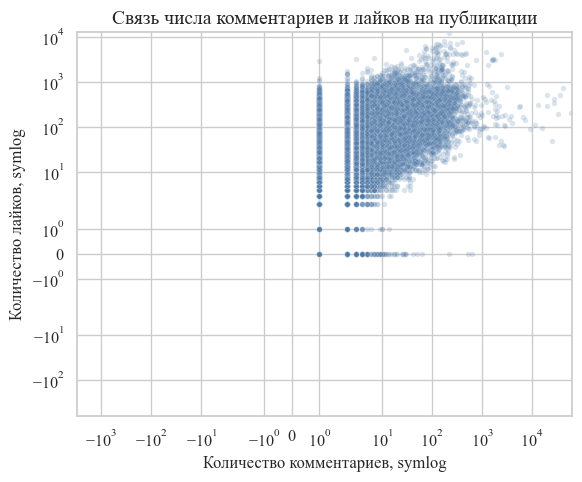

In [43]:
comm_corr = data_with_comments[['comments_count', 'comments_len', 'comments_word_cnt_mean', 'engagement', 'likes', 'views', 'reposts']].corr(method='spearman')
display(comm_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(comm_corr, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Корреляции Спирмена между метриками')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=data_with_comments, x='comments_count', y='likes',
               s=15, alpha=0.2, ax=ax, color='#4C78A8')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_title('Связь числа комментариев и лайков на публикации')
ax.set_xlabel('Количество комментариев, symlog')
ax.set_ylabel('Количество лайков, symlog')
plt.tight_layout()
plt.show()

Основная масса точек на графике расположена в зоне сравнительно небольшого и среднего числа комментариев и лайков. При этом разброс остается по-прежнему большим: при одном количестве комментариев, число лайков может варьироваться.

Число комментариев и лайков коррелируют положительно с силой 0,44  
Число комментариев и просмотров коррелируют положительно с силой 0,34  
Число комментариев и репостов коррелируют положительно с силой 0,26  
Число просмотров и вовлеченность коррелируют  с силой 0,74  

Корреляционная матрица позволяет сказать, что массовые обсуждения часто состоят из более коротких комментариев, а менее массовые – могут содержать более развернутые комментарии.

## Выводы EDA

* Полная таблица содержит 345004 публикаций из 90 источников, диапазон дат включает период с 01.01.2020 по 31.12.2025.
* Таблица с текстами комментариев содержит 99279 строк, что составляет около 29% от всех публикаций в выборке.
* Публикационная активность вузов возрастает к 2025 году, пик активности – апрель 2025.
* Распределения лайков, комментариев, репостов и просмотров являются скошенными. Медианные значения устойчивее средних.
* Была обнаружена корреляция между числом комментариев и лайками, комментариев и просмотрами, комментариев и репостами; между числом просмотров и вовлеченности. Данные связи являются статистическими, а не причинными.